In [ ]:
# import libaries
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ( accuracy_score, precision_score,recall_score,
 f1_score,confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

In [ ]:
#Load Dataset
iris = load_iris()
df = pd.DataFrame(iris.data,columns=iris.feature_names)
df['species'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
df.shape

(150, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [ ]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


The Iris dataset contains 150 flower samples.
It has four numerical features:
sepal length, sepal width, petal length, and petal width.
The target variable is species.
There are three flower classes.
No missing values are present.

Preprocessing Summary

1. The Iris dataset was loaded using Scikit-learn.
2. Missing values were checked and none were found.
3. No categorical variables were present, so encoding was not required.
4. Features and target variable were separated.
5. The dataset was split into training (80%) and testing (20%) sets.

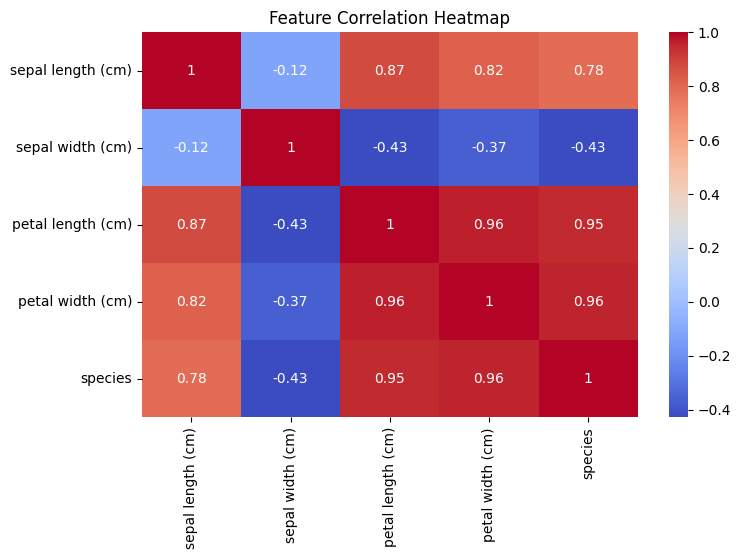

In [ ]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

Feature Engineering

Correlation analysis was performed to identify relationships between features and the target variable. Petal length and petal width showed the strongest correlation with species, indicating that these features are highly important for classification.

In [ ]:
X = df.drop('species', axis=1)
y = df['species']

In [ ]:
#train test split 80/20
X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.20,random_state=42)

In [ ]:
#model1 by logistic regression
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [ ]:
#model2 random forest
rf = RandomForestClassifier( n_estimators=100,random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [ ]:
#model3 knn
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

In [ ]:
def evaluate_model(y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_true,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average='weighted'
    )

    return accuracy, precision, recall, f1

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'KNN'
    ],
    'Accuracy': [
        evaluate_model(y_test, lr_pred)[0],
        evaluate_model(y_test, rf_pred)[0],
        evaluate_model(y_test, knn_pred)[0]
    ],
    'Precision': [
        evaluate_model(y_test, lr_pred)[1],
        evaluate_model(y_test, rf_pred)[1],
        evaluate_model(y_test, knn_pred)[1]
    ],
    'Recall': [
        evaluate_model(y_test, lr_pred)[2],
        evaluate_model(y_test, rf_pred)[2],
        evaluate_model(y_test, knn_pred)[2]
    ],
    'F1 Score': [
        evaluate_model(y_test, lr_pred)[3],
        evaluate_model(y_test, rf_pred)[3],
        evaluate_model(y_test, knn_pred)[3]
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0
2,KNN,1.0,1.0,1.0,1.0


Best Model Analysis

All three models achieved perfect accuracy on the test dataset. Random Forest was selected as the best model because it is robust, handles feature interactions effectively, and performs well on unseen data. The confusion matrix also confirms perfect classification performance.

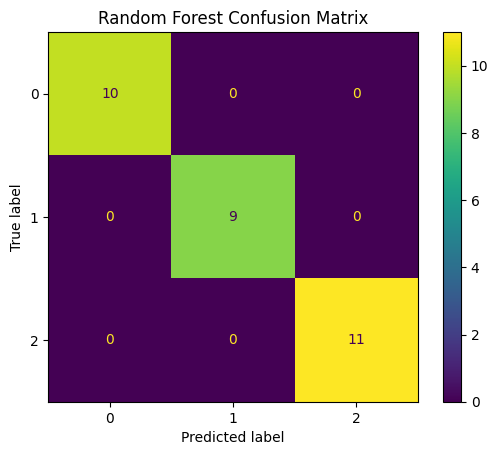

In [ ]:
best_pred = rf_pred
cm = confusion_matrix(y_test,best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Random Forest Confusion Matrix')
plt.show()

Conclusion

1. Three machine learning models were trained and evaluated on the Iris dataset.
2. Logistic Regression, Random Forest, and KNN achieved excellent performance.
3. Random Forest was selected as the best model for final analysis.
4. The confusion matrix showed that the model classified all test samples correctly.
5. The project demonstrates how machine learning can accurately classify flower species using simple numerical features.